# MNIST Classification With CNN
> This file was downloaded from Google Colab

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


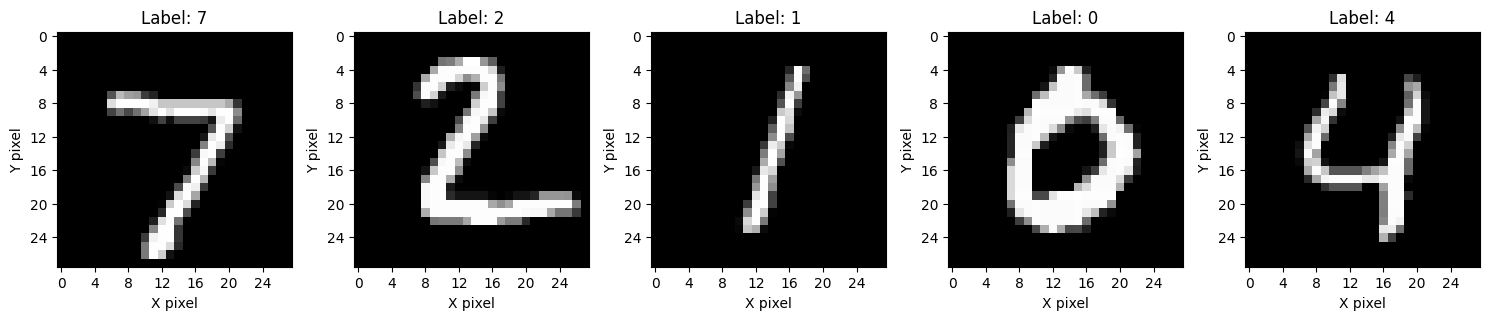

In [35]:
"""
Since there is no downloaded MNIST dataset on Google Colab, 
the code in this cell is used to download the dataset directly 
from `http://yann.lecun.com/exdb/mnist` through python code 
and decompress it in the current directory. After this code 
is executed, the code of the following cell can be executed 
to train the CNN model.
"""

"""
Daniel Wu, 3/11/26
Group4
CPSC476, Spring 2026
Professor Ning Chen
"""

import urllib.request
import gzip
import numpy as np
import os

# Download the MNIST dataset files
def download_mnist(url, filename):
    urllib.request.urlretrieve(url, filename)

# Extract the MNIST dataset files
def extract_mnist(filename, save_dir):
    with gzip.open(filename, 'rb') as f_in:
        with open(save_dir, 'wb') as f_out:
            f_out.write(f_in.read())

# Load MNIST image data
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        # Skip the file header
        f.read(16)
        # Read the image data
        buf = f.read()
        data = np.frombuffer(buf, dtype=np.uint8).reshape(-1, 28, 28)
    return data

# Load MNIST label data
def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        # Skip the file header
        f.read(8)
        # Read the label data
        buf = f.read()
        data = np.frombuffer(buf, dtype=np.uint8)
    return data


os.makedirs("./data", exist_ok=True)

"""
#fix certification issues - did not work (gave up and downloaded the file manually)
%pip install --upgrade certifi
import ssl
import certifi
import urllib.request
# Use certifi's certificate bundle
ssl_context = ssl.create_default_context(cafile=certifi.where())
import os
os.environ['SSL_CERT_FILE'] = certifi.where()
#end certification issues
"""

# Download MNIST dataset files (just download and save inside folder)
#download_mnist('http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz', './data/train-images-idx3-ubyte.gz')
#download_mnist('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz', './data/train-images-idx3-ubyte.gz')
#download_mnist('http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz', './data/train-labels-idx1-ubyte.gz')
#download_mnist('http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz', './data/t10k-images-idx3-ubyte.gz')
#download_mnist('http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz', './data/t10k-labels-idx1-ubyte.gz')

# Extract MNIST dataset files
extract_mnist('./data/train-images-idx3-ubyte.gz', './data/train-images.idx3-ubyte')
extract_mnist('./data/train-labels-idx1-ubyte.gz', './data/train-labels.idx1-ubyte')
extract_mnist('./data/t10k-images-idx3-ubyte.gz', './data/t10k-images.idx3-ubyte')
extract_mnist('./data/t10k-labels-idx1-ubyte.gz', './data/t10k-labels.idx1-ubyte')

# Load training and test set data
train_images = load_mnist_images('./data/train-images.idx3-ubyte')
train_labels = load_mnist_labels('./data/train-labels.idx1-ubyte')
test_images = load_mnist_images('./data/t10k-images.idx3-ubyte')
test_labels = load_mnist_labels('./data/t10k-labels.idx1-ubyte')

# Print the shapes of the datasets
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

# drawing plots
import matplotlib.pyplot as plt

num_plots = 5
fig, axes = plt.subplots(1, num_plots, figsize=(15,3))

for i in range(num_plots):
    ax = axes[i]
    ax.imshow(test_images[i], cmap='gray')
    
    # Label axes 0–27
    ax.set_xticks(range(0,28,4))
    ax.set_yticks(range(0,28,4))
    
    ax.set_xlabel("X pixel")
    ax.set_ylabel("Y pixel")
    ax.set_title(f"Label: {test_labels[i]}")
    
plt.tight_layout()
plt.show()

In [36]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

IMAGE_SIZE = 28 * 28  # MNIST image size


def load_mnist(path, kind='train'):

    """
    'train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz',
    't10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz'
    Before use, you need to download the above four files to the `path` directory and unzip them
    """
    labels_path = os.path.join(path, '%s-labels.idx1-ubyte' % kind)
    images_path = os.path.join(path, '%s-images.idx3-ubyte' % kind)

    with open(labels_path, 'rb') as label_file:
        labels = np.frombuffer(label_file.read(), dtype=np.uint8, offset=8)

    with open(images_path, 'rb') as image_file:
        images = np.frombuffer(image_file.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), IMAGE_SIZE)

    return images, labels


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=3)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(64, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.relu3 = nn.ReLU()

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3)
        self.relu4 = nn.ReLU()
        self.maxpool4 = nn.MaxPool2d(kernel_size=2)
        self.bn4 = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128, 256, kernel_size=3)
        self.relu5 = nn.ReLU()
        self.maxpool5 = nn.MaxPool2d(kernel_size=2)
        self.bn5 = nn.BatchNorm2d(256)

        self.flatten = nn.Flatten()

        self.linear1 = nn.Linear(256, 512)
        self.relu6 = nn.ReLU()

        self.linear2 = nn.Linear(512, 10)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.maxpool2(x)
        x = self.bn2(x)

        x = self.conv3(x)
        x = self.relu3(x)

        x = self.conv4(x)
        x = self.relu4(x)
        x = self.maxpool4(x)
        x = self.bn4(x)

        x = self.conv5(x)
        x = self.relu5(x)
        x = self.maxpool5(x)
        x = self.bn5(x)

        x = self.flatten(x)

        x = self.linear1(x)
        x = self.relu6(x)

        x = self.linear2(x)
        x = self.softmax(x)
        return x


def train(train_loader, num_epochs, optimizer, scheduler, device):
    total_step = len(train_loader)
    model.train()
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # forward prop
            outputs = model(images)
            loss = criterion(outputs, labels)

            # backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # update learning rate
            scheduler.step()

            # print results every 100 steps
            if (i + 1) % 100 == 0:
                print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Learning Rate: {:.10f}'
                      .format(epoch + 1, num_epochs, i + 1, total_step, loss.item(), scheduler.get_last_lr()[0]))


def test(model, test_loader, device):
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print('Accuracy on test set: {:.2f} %'.format(100 * correct / total))


#if __name__ == "__main__":
data_path = './data'

# set random seed to make the result repeatable
torch.manual_seed(0)

# hyper parameters
batch_size = 128
num_epochs = 13
learning_rate = 0.001

# check if CUDA is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# load train set
train_images, train_labels = load_mnist(data_path, kind='train')
train_images = train_images.reshape(-1, 1, 28, 28)  # reshape the size to match the input of CNN

# load test set
test_images, test_labels = load_mnist(data_path, kind='t10k')
test_images = test_images.reshape(-1, 1, 28, 28)  # convert flattened images into CNN format

# numpy to tensor
train_images = torch.from_numpy(train_images.copy()).float()
train_labels = torch.from_numpy(train_labels.copy()).long()
test_images = torch.from_numpy(test_images.copy()).float()
test_labels = torch.from_numpy(test_labels.copy()).long()

# create dataset objects
train_dataset = torch.utils.data.TensorDataset(train_images, train_labels)
test_dataset = torch.utils.data.TensorDataset(test_images, test_labels)

# create dataset loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# initialize model and loss fn
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# learning rate scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=469 * 2, gamma=0.1)


#split the code for easy testing
    


Using device: cpu


In [37]:
# Train the model, test it, and save.
# train
print("\nTraining: ")
train(
    train_loader=train_loader,
    num_epochs=num_epochs,
    optimizer=optimizer,
    device=device,
    scheduler=scheduler
)
#saving the model as a pythorch model file (parameters only, no architecture)
torch.save(model.state_dict(), 'model.pth')

#to load it later, need to reconstruct the architecture as follow to load in the future
#model = CNN().to(device)          # define architecture
#model.load_state_dict(torch.load("model.pth"))
#model.eval()

#Another way to save the model is using keras/tensorflow
#this one will save the architecture
#model.save("mnist_cnn_model.h5")

#need to use the following command to load the model from keras/tensorflow
#from tensorflow.keras.models import load_model
#model = load_model("mnist_cnn_model.h5")

# this the 3rd way: saving using keras (new)
# model.save("mnist_cnn_model.keras")

# test
print('\nTesting using trained model...')

test(
    test_loader=test_loader,
    model=model,
    device=device
)


Training: 
Epoch [1/13], Step [100/469], Loss: 1.4700, Learning Rate: 0.0010000000
Epoch [1/13], Step [200/469], Loss: 1.4630, Learning Rate: 0.0010000000
Epoch [1/13], Step [300/469], Loss: 1.4821, Learning Rate: 0.0010000000
Epoch [1/13], Step [400/469], Loss: 1.4885, Learning Rate: 0.0010000000
Epoch [2/13], Step [100/469], Loss: 1.4613, Learning Rate: 0.0010000000
Epoch [2/13], Step [200/469], Loss: 1.4698, Learning Rate: 0.0010000000
Epoch [2/13], Step [300/469], Loss: 1.4760, Learning Rate: 0.0010000000
Epoch [2/13], Step [400/469], Loss: 1.4789, Learning Rate: 0.0010000000
Epoch [3/13], Step [100/469], Loss: 1.4686, Learning Rate: 0.0001000000
Epoch [3/13], Step [200/469], Loss: 1.4768, Learning Rate: 0.0001000000
Epoch [3/13], Step [300/469], Loss: 1.4648, Learning Rate: 0.0001000000
Epoch [3/13], Step [400/469], Loss: 1.4778, Learning Rate: 0.0001000000
Epoch [4/13], Step [100/469], Loss: 1.4612, Learning Rate: 0.0001000000
Epoch [4/13], Step [200/469], Loss: 1.4730, Learning

In [38]:
#loading from a pre-trained model. Compare original test with 3 smaller groups.

# if __name__ == "__main__":
from torch.utils.data import random_split
    
batch_size = 128
    
# load test set
test_images, test_labels = load_mnist(data_path, kind='t10k')
test_images = test_images.reshape(-1, 1, 28, 28)  # convert flattened image into CNN format

# numpy to tensor
test_images = torch.from_numpy(test_images.copy()).float()
test_labels = torch.from_numpy(test_labels.copy()).long()

# create dataset object
test_dataset = torch.utils.data.TensorDataset(test_images, test_labels)

from torch.utils.data import random_split

# total number of test samples
num_test_samples = len(test_dataset)

# define the sizes of the splits
split1_size = num_test_samples // 3           # 1/3
split2_size = num_test_samples // 3           # 1/3
split3_size = num_test_samples - split1_size - split2_size # remaining 1/3

# split the dataset
test_dataset1, test_dataset2, test_dataset3 = random_split(test_dataset, [split1_size, split2_size, split3_size])

batch_size = 128  # can be same as training

test_loader1 = torch.utils.data.DataLoader(test_dataset1, batch_size=batch_size, shuffle=False)
test_loader2 = torch.utils.data.DataLoader(test_dataset2, batch_size=batch_size, shuffle=False)
test_loader3 = torch.utils.data.DataLoader(test_dataset3, batch_size=batch_size, shuffle=False)


#loading from save file
model2 = CNN().to(device)          # define architecture
model2.load_state_dict(torch.load("model.pth"))
model2.eval()

# Testing models
print("Testing on same test set:")
test(test_loader=test_loader, model = model2, device=device)

print("Testing on test set 1/3:")
test(test_loader=test_loader1, model = model2, device=device)

print("Testing on test set 2/3:")
test(test_loader=test_loader2, model = model2, device=device)

print("Testing on test set 3/3:")
test(test_loader=test_loader3, model = model2, device=device)


 

Testing on same test set:
Accuracy on test set: 99.51 %
Testing on test set 1/3:
Accuracy on test set: 99.61 %
Testing on test set 2/3:
Accuracy on test set: 99.52 %
Testing on test set 3/3:
Accuracy on test set: 99.40 %
